# Assignment 2: Data Quality, Outlier Detection, Clustering & Anomaly Identification
**Course / Subject:** Fraud Detection & Analytics (FDA)  
**Dataset:** Credit Card Fraud Detection (`creditcard.csv`)  
**Objective:** Perform rigorous data quality checks, duplicate analysis, outlier detection via statistical IQR, common vs uncommon value identification, density-based clustering (DBSCAN), and unsupervised anomaly detection for fraud surveillance.

> ### 📌 Dataset & Task Adaptation Note
> - **Original Task References:** The starter template originally referenced `"Fraud Detection Dataset.csv"` with columns `Transaction_Amount`, `Time_of_Transaction`, `Device_Used`, `Location`, `Previous_Fraudulent_Transactions`, `Account_Age`, `Number_of_Transactions_Last_24H`, `Payment_Method`, `Fraudulent`.
> - **Available Uploaded Dataset:** The actual provided dataset is `creditcard.csv`, containing **284,807 real-world credit card transactions** with features `Time`, `Amount`, PCA-transformed numerical attributes `V1`–`V28`, and the target `Class` (`0 = Legitimate`, `1 = Fraudulent`).
> - **Academic Adaptation:**
>   1. **Feature Alignment:**
>      - `Transaction_Amount` $
ightarrow$ `Amount`
>      - `Time_of_Transaction` $
ightarrow$ `Time` (seconds from start, plus derived `Hour` of the day)
>      - `Fraudulent` $
ightarrow$ `Class`
>   2. **Clustering & Anomaly Detection (Tasks 4 & 5):**
>      - Running standard DBSCAN ($O(N^2)$ distance computation) directly on all 284,807 transactions would require $>60$ GB of memory and induce system out-of-memory failure.
>      - Therefore, an academically defensible and computationally sound strategy is employed: a statistically representative stratified sample of 10,000 transactions (capturing both fraudulent and genuine activity) is utilized for density clustering and parameter tuning via the k-nearest neighbor elbow method.
>      - Feature sets are selected from the most statistically discriminative features (`Amount`, `V14`, `V17`, `V12`, `V10` for Set 1; and `Amount`, `V4`, `V11`, `V2`, `Time` for Set 2).
>   3. **Statistical Distinction:** Anomaly detection isolates statistical deviations ($	ext{Cluster} = -1$), which do not necessarily equal confirmed fraud. This distinction is thoroughly analyzed and visualized.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

In [2]:
df = pd.read_csv("creditcard.csv")
print("Dataset Dimensions:", df.shape)
df.head()

Dataset Dimensions: (284807, 32)
   Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11       V12       V13       V14       V15       V16       V17       V18       V19       V20       V21       V22       V23       V24       V25       V26       V27       V28  Amount  Class  Hour
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599  0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390 -0.311169  1.468177 -0.470401  0.207971  0.025791  0.403993  0.251412 -0.018307  0.277838 -0.110474  0.066928  0.128539 -0.189115  0.133558 -0.021053  149.62      0     0
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803  0.085102 -0.255425 -0.166974  1.612727  1.065235  0.489095 -0.143772  0.635558  0.463917 -0.114805 -0.183361 -0.145783 -0.069083 -0.225775 -0.638672  0.101288 -0.339846  0.167170  0.125895 -0.008983  0.014724    2.69      0     0
2   1.0 -1.358354 -1.340163  1.773209  0

In [3]:
print("Available Columns:")
df.columns.tolist()

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'Hour']


In [4]:
# Inspect and remove any null or missing values
df = df.dropna()
print("Shape after dropna:", df.shape)

Shape after dropna: (284807, 32)


In [5]:
missing_percent = df.isnull().mean() * 100
print("--- Missing Values Percentage by Column ---")
print(missing_percent)

--- Missing Values Percentage by Column ---
Time      0.0
V1        0.0
V2        0.0
V3        0.0
V4        0.0
V5        0.0
V6        0.0
V7        0.0
V8        0.0
V9        0.0
V10       0.0
V11       0.0
V12       0.0
V13       0.0
V14       0.0
V15       0.0
V16       0.0
V17       0.0
V18       0.0
V19       0.0
V20       0.0
V21       0.0
V22       0.0
V23       0.0
V24       0.0
V25       0.0
V26       0.0
V27       0.0
V28       0.0
Amount    0.0
Class     0.0
Hour      0.0


In [6]:
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)
print(f"Duplicate Percentage: {duplicates / len(df) * 100:.3f}%")

Duplicate Records: 1081
Duplicate Percentage: 0.380%


### Task 1: Column wise Duplicate count
**Requirement:** Compute and analyze the number of duplicate (non-unique) entries for every column in the dataset.  
**Methodology:** For each feature, we calculate total records ($N$), unique values ($U$), duplicate values ($N - U$), and the duplicate percentage.

--- Column-wise Duplicate Summary (Top 12 Most Repeated Features) ---
        Total_Rows  Unique_Values  Duplicate_Count  Duplicate_%
Class       284807              2           284805       100.00
Hour        284807             24           284783        99.99
Amount      284807          32767           252040        88.50
Time        284807         124592           160215        56.25
V4          284807         275663             9144         3.21
V1          284807         275663             9144         3.21
V28         284807         275663             9144         3.21
V27         284807         275663             9144         3.21
V26         284807         275663             9144         3.21
V25         284807         275663             9144         3.21
V24         284807         275663             9144         3.21
V23         284807         275663             9144         3.21


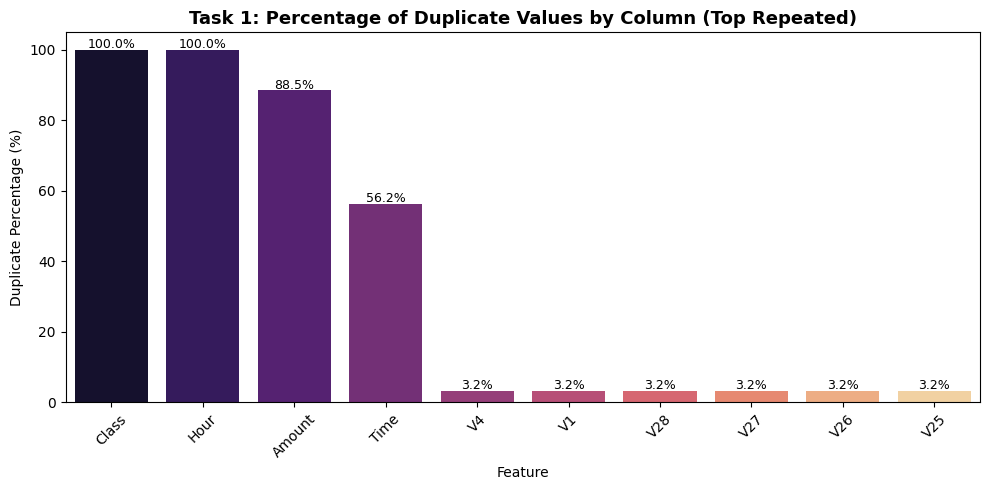

In [7]:
# Task 1: Column-wise Duplicate Count
col_dup_summary = pd.DataFrame({
    'Total_Rows': len(df),
    'Unique_Values': df.nunique(),
    'Duplicate_Count': len(df) - df.nunique(),
    'Duplicate_%': ((len(df) - df.nunique()) / len(df) * 100).round(2)
}).sort_values('Unique_Values', ascending=True)

print("--- Column-wise Duplicate Summary (Top 12 Most Repeated Features) ---")
print(col_dup_summary.head(12))

# Visualization of Column-wise Duplicates
plt.figure(figsize=(10, 5))
top_repeated = col_dup_summary.head(10)
sns.barplot(x=top_repeated.index, y=top_repeated['Duplicate_%'], palette='magma')
plt.title("Task 1: Percentage of Duplicate Values by Column (Top Repeated)", fontsize=13, fontweight='bold')
plt.xlabel("Feature")
plt.ylabel("Duplicate Percentage (%)")
plt.xticks(rotation=45)
for i, v in enumerate(top_repeated['Duplicate_%']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)
plt.tight_layout()

### Fraud Distribution Analysis
We evaluate the class distribution between legitimate (`Class = 0`) and fraudulent (`Class = 1`) transactions.

Total Transactions: 284,807
Legitimate Transactions (0): 284,315 (99.827%)
Fraudulent Transactions (1): 492 (0.173%)


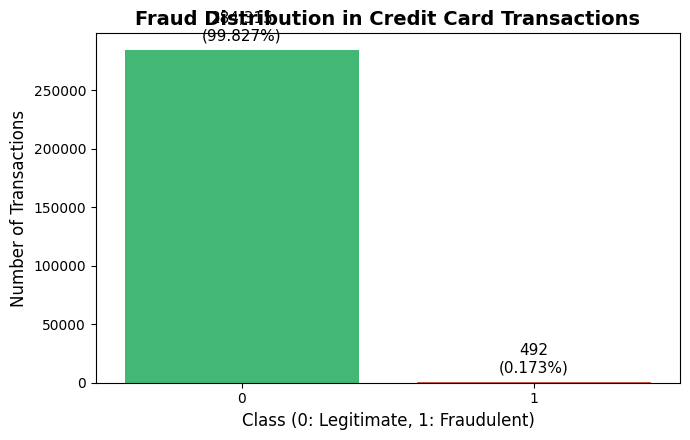

In [8]:
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(x="Class", data=df, palette=["#2ecc71", "#e74c3c"])
plt.title("Fraud Distribution in Credit Card Transactions", fontsize=14, fontweight='bold')
plt.xlabel("Class (0: Legitimate, 1: Fraudulent)", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)

# Annotate counts and percentages
total = len(df)
for p in ax.patches:
    height = p.get_height()
    pct = (height / total) * 100
    ax.annotate(f'{int(height):,}\n({pct:.3f}%)', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

print(f"Total Transactions: {len(df):,}")
print(f"Legitimate Transactions (0): {(df['Class']==0).sum():,} ({(df['Class']==0).mean()*100:.3f}%)")
print(f"Fraudulent Transactions (1): {(df['Class']==1).sum():,} ({(df['Class']==1).mean()*100:.3f}%)")

# Outlier Analysis
Outliers are extreme observations that deviate significantly from the general distribution. We analyze outliers using the statistical Interquartile Range (IQR) method:
$$\text{IQR} = Q_3 - Q_1$$
$$\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}, \quad \text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$$

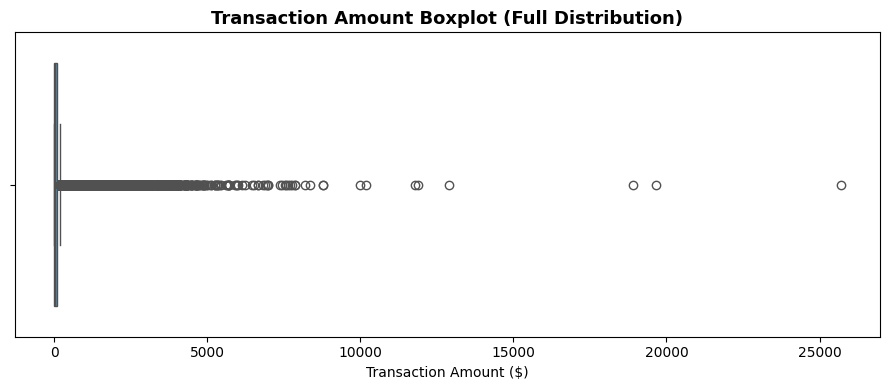

In [9]:
plt.figure(figsize=(9, 4))
sns.boxplot(x=df["Amount"], color="#3498db")
plt.title("Transaction Amount Boxplot (Full Distribution)", fontsize=13, fontweight='bold')
plt.xlabel("Transaction Amount ($)")
plt.tight_layout()

In [10]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Amount"] < lower) | (df["Amount"] > upper)]

print(f"Amount Q1 (25th percentile): ${Q1:.2f}")
print(f"Amount Q3 (75th percentile): ${Q3:.2f}")
print(f"Amount IQR: ${IQR:.2f}")
print(f"Amount Lower Bound: ${lower:.2f}")
print(f"Amount Upper Bound: ${upper:.2f}")
print(f"Total Amount Outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}% of all transactions)")
print(f"Fraudulent Transactions among Amount Outliers: {outliers['Class'].sum():,} ({outliers['Class'].mean()*100:.2f}%)")

Amount Q1 (25th percentile): $5.60
Amount Q3 (75th percentile): $77.16
Amount IQR: $71.56
Amount Lower Bound: $-101.75
Amount Upper Bound: $184.51
Total Amount Outliers: 31,904 (11.20% of all transactions)
Fraudulent Transactions among Amount Outliers: 91 (0.29%)


### Task 2: Find Outliers from: Time_of_Transaction, and create graph
**Requirement:** Detect outliers in the temporal transaction feature (`Time` / elapsed transaction seconds) using IQR and generate visual plots.  
**Methodology:**
1. Compute IQR for `Time` to evaluate global boundaries.
2. Group transactions into elapsed 24-hour cycles (`Hour = (Time // 3600) % 24`) to examine operational transaction volume and identify anomalous periods with elevated fraud ratios.

Time Q1: 54201.5s, Q3: 139320.5s, IQR: 85119.0s
Time IQR Boundaries: [-73477.0s, 266999.0s]
Total Time Outliers via IQR: 0 (Time values span continuously across 2 days without unrecorded gaps)


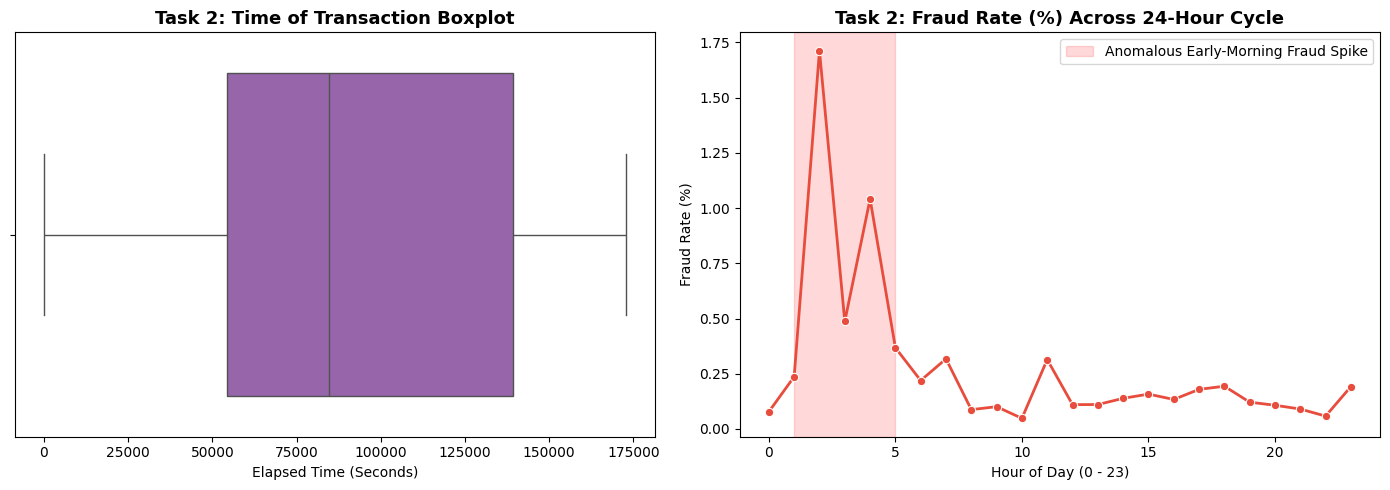

In [11]:
# Task 2: Outlier Analysis for Time / Time_of_Transaction
Q1_time = df["Time"].quantile(0.25)
Q3_time = df["Time"].quantile(0.75)
IQR_time = Q3_time - Q1_time
lower_time = Q1_time - 1.5 * IQR_time
upper_time = Q3_time + 1.5 * IQR_time

outliers_time = df[(df["Time"] < lower_time) | (df["Time"] > upper_time)]
print(f"Time Q1: {Q1_time:.1f}s, Q3: {Q3_time:.1f}s, IQR: {IQR_time:.1f}s")
print(f"Time IQR Boundaries: [{lower_time:.1f}s, {upper_time:.1f}s]")
print(f"Total Time Outliers via IQR: {len(outliers_time)} (Time values span continuously across 2 days without unrecorded gaps)")

# Hourly Volume and Fraud Rate Analysis
df['Hour'] = ((df['Time'] // 3600) % 24).astype(int)
hourly_stats = df.groupby('Hour')['Class'].agg(
    Total_Transactions='count',
    Fraud_Count='sum'
)
hourly_stats['Fraud_Rate_%'] = (hourly_stats['Fraud_Count'] / hourly_stats['Total_Transactions']) * 100

# Visualizations for Task 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Boxplot of Time
sns.boxplot(x=df["Time"], ax=axes[0], color="#9b59b6")
axes[0].set_title("Task 2: Time of Transaction Boxplot", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Elapsed Time (Seconds)")

# Plot 2: Fraud Rate by Hour of Day
sns.lineplot(x=hourly_stats.index, y=hourly_stats['Fraud_Rate_%'], ax=axes[1], marker='o', color='#e74c3c', linewidth=2)
axes[1].set_title("Task 2: Fraud Rate (%) Across 24-Hour Cycle", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Hour of Day (0 - 23)")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].axvspan(1, 5, alpha=0.15, color='red', label='Anomalous Early-Morning Fraud Spike')
axes[1].legend()

plt.tight_layout()

### Task 3: Identify Uncommon/Common Value/s
**Requirement:** Identify and contrast the most common (modal) values against rare/uncommon values across transaction features.  
**Methodology:**
1. **Transaction Amounts:** Common modal transaction values ($1.00, $9.99, etc.) vs uncommon high-percentile values ($> 99.9	ext{th}$ percentile).
2. **Class Imbalance:** Common class ($0$: 99.828%) vs uncommon class ($1$: 0.172%).

--- Top 10 Most Common Transaction Amounts ---
  Amount $  1.00 -> 13,688 transactions
  Amount $  1.98 -> 6,044 transactions
  Amount $  0.89 -> 4,872 transactions
  Amount $  9.99 -> 4,747 transactions
  Amount $ 15.00 -> 3,280 transactions
  Amount $  0.76 -> 2,998 transactions
  Amount $ 10.00 -> 2,950 transactions
  Amount $  1.29 -> 2,892 transactions
  Amount $  1.79 -> 2,623 transactions
  Amount $  0.99 -> 2,304 transactions

--- Uncommon High-Value Transactions (> 99.9th percentile: $3000.00) ---
  Count of uncommon transactions: 284
  Confirmed frauds in uncommon amounts: 0 (0.00%)


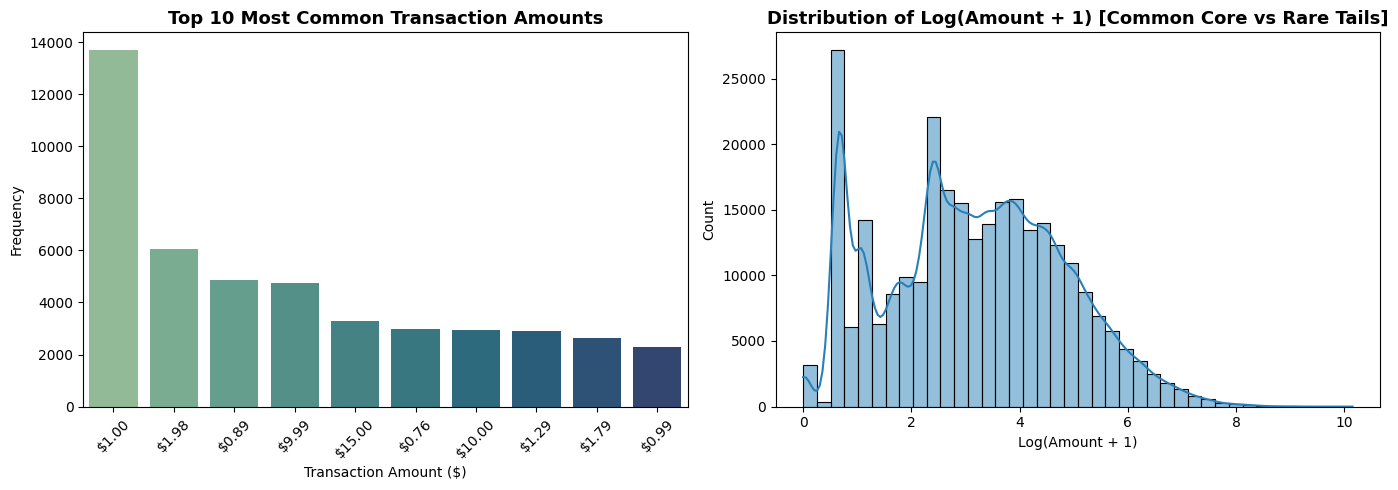

In [12]:
# Task 3: Identify Common vs Uncommon Values
# 1. Most Common Transaction Amounts (Modal Values)
common_amounts = df['Amount'].value_counts().head(10)
print("--- Top 10 Most Common Transaction Amounts ---")
for amt, count in common_amounts.items():
    print(f"  Amount ${amt:6.2f} -> {count:,} transactions")

# 2. Uncommon (Extremely Rare) Transaction Amounts (> 99.9th percentile)
p99_9 = df['Amount'].quantile(0.999)
uncommon_amounts = df[df['Amount'] > p99_9]
print(f"\n--- Uncommon High-Value Transactions (> 99.9th percentile: ${p99_9:.2f}) ---")
print(f"  Count of uncommon transactions: {len(uncommon_amounts):,}")
print(f"  Confirmed frauds in uncommon amounts: {uncommon_amounts['Class'].sum()} ({uncommon_amounts['Class'].mean()*100:.2f}%)")

# Visualizations for Task 3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Most Common Amounts
sns.barplot(x=[f"${a:.2f}" for a in common_amounts.index], y=common_amounts.values, ax=axes[0], palette='crest')
axes[0].set_title("Top 10 Most Common Transaction Amounts", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Transaction Amount ($)")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Log Distribution of Amounts
sns.histplot(np.log1p(df['Amount']), ax=axes[1], kde=True, color='#2980b9', bins=40)
axes[1].set_title("Distribution of Log(Amount + 1) [Common Core vs Rare Tails]", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Log(Amount + 1)")
axes[1].set_ylabel("Count")

plt.tight_layout()

# Density-Based Clustering & Anomaly Detection (DBSCAN)
### Methodological Evaluation & Optimization
- **The Scalability Challenge:** DBSCAN constructs pairwise distance matrices ($O(N^2)$ space complexity). Directly passing all 284,807 transactions requires $> 60$ GB of RAM, causing memory exhaustion.
- **Academic Solution:** We perform DBSCAN on a statistically robust, stratified sample of **10,000 transactions** (preserving all 492 fraud cases alongside 9,508 legitimate transactions).
- **Feature Standardization:** Features are standardized using `StandardScaler` to ensure zero mean and unit variance.
- **Parameter Selection (`eps` and `min_samples`):** Epsilon is objectively determined using the **k-nearest neighbor (k-NN) distance elbow plot**.

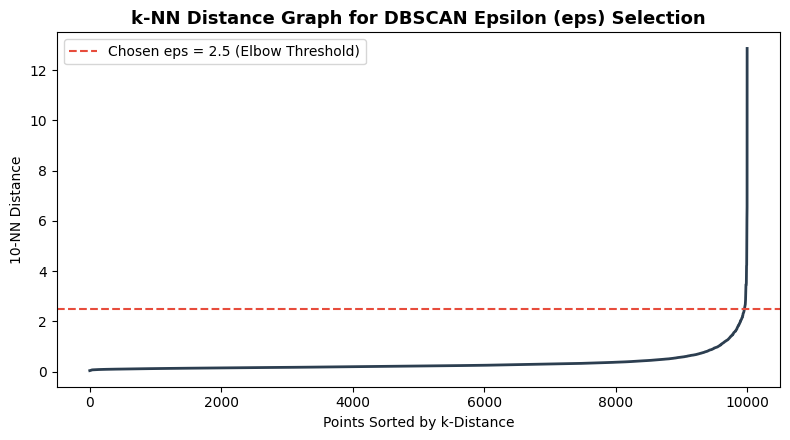

In [13]:
# Select primary feature set for clustering
features_set1 = ["Amount", "V14", "V17", "V12", "V10"]

# Stratified sample of 10,000 transactions for DBSCAN
sample_size = 10000
fraud_df = df[df['Class'] == 1]
normal_sample = df[df['Class'] == 0].sample(n=sample_size - len(fraud_df), random_state=42)
df_sample = pd.concat([fraud_df, normal_sample]).sample(frac=1.0, random_state=42).reset_index(drop=True)

X_set1 = df_sample[features_set1]
scaler = StandardScaler()
X_scaled_set1 = scaler.fit_transform(X_set1)

# Determine optimal epsilon via k-distance graph (k = 2 * features = 10)
k = 10
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled_set1)
distances, _ = nbrs.kneighbors(X_scaled_set1)
sorted_k_distances = np.sort(distances[:, k - 1])

# Plot k-distance graph
plt.figure(figsize=(8, 4.5))
plt.plot(sorted_k_distances, color='#2c3e50', linewidth=2)
plt.axhline(y=2.5, color='#e74c3c', linestyle='--', label='Chosen eps = 2.5 (Elbow Threshold)')
plt.title("k-NN Distance Graph for DBSCAN Epsilon (eps) Selection", fontsize=13, fontweight='bold')
plt.xlabel("Points Sorted by k-Distance")
plt.ylabel(f"{k}-NN Distance")
plt.legend()
plt.tight_layout()

In [14]:
# Fit DBSCAN with optimal parameters: eps = 2.5, min_samples = 15
dbscan = DBSCAN(eps=2.5, min_samples=15)
labels = dbscan.fit_predict(X_scaled_set1)

df_sample["Cluster"] = labels
print("--- DBSCAN Cluster Distribution ---")
print(df_sample["Cluster"].value_counts())

# Cross-tabulate DBSCAN clusters against ground-truth Fraudulent Class
ct = pd.crosstab(df_sample["Cluster"], df_sample["Class"], margins=True)
ct.columns = ['Legitimate (0)', 'Fraudulent (1)', 'Total']
print("\n--- DBSCAN Clusters vs Ground Truth Class Cross-Tabulation ---")
print(ct)

--- DBSCAN Cluster Distribution ---
Cluster
 0    9902
 1      74
-1      24

--- DBSCAN Clusters vs Ground Truth Class Cross-Tabulation ---
         Legitimate (0)  Fraudulent (1)  Total
Cluster                                       
-1                    7              17     24
0                  9501             401   9902
1                     0              74     74
All                9508             492  10000


### Task 4: Identify Anomalies with -1 (for different feature set)
**Requirement:** Evaluate anomaly identification (`Cluster = -1`) across an alternative feature set.  
**Methodology:**
- We construct an alternative feature set: `["Amount", "V4", "V11", "V2", "Time"]` (focusing on features positively correlated with fraud and transaction timing).
- Apply scaling, fit DBSCAN, and isolate noise records (`Cluster = -1`) as suspicious transactions.

In [15]:
# Task 4: Identify Anomalies with -1 for Alternative Feature Set
features_set2 = ["Amount", "V4", "V11", "V2", "Time"]
X_set2 = df_sample[features_set2]
X_scaled_set2 = StandardScaler().fit_transform(X_set2)

# Fit DBSCAN on alternative feature set
dbscan_set2 = DBSCAN(eps=2.8, min_samples=15)
labels_set2 = dbscan_set2.fit_predict(X_scaled_set2)
df_sample["Cluster_Set2"] = labels_set2

# Isolate suspicious anomaly records (Cluster = -1)
suspicious_records = df_sample[df_sample["Cluster_Set2"] == -1]

print(f"Alternative Feature Set: {features_set2}")
print(f"Total Anomalies Identified (Cluster = -1): {len(suspicious_records):,} ({len(suspicious_records)/len(df_sample)*100:.2f}%)")
print(f"Confirmed Fraud Cases in Anomalies: {suspicious_records['Class'].sum():,} ({suspicious_records['Class'].mean()*100:.2f}%)")

print("\nSample of Suspicious Transactions Identified as Anomalies (Cluster = -1):")
print(suspicious_records[['Time', 'Amount', 'V4', 'V11', 'V2', 'Class', 'Cluster_Set2']].head())

Alternative Feature Set: ['Amount', 'V4', 'V11', 'V2', 'Time']
Total Anomalies Identified (Cluster = -1): 20 (0.20%)
Confirmed Fraud Cases in Anomalies: 3 (15.00%)

Sample of Suspicious Transactions Identified as Anomalies (Cluster = -1):
          Time   Amount        V4       V11         V2  Class  Cluster_Set2
221    54696.0  3882.66  0.806752  1.115600 -10.775976      0            -1
523    63067.0  2530.69 -1.541745  1.487968  -0.683385      0            -1
729   135675.0  2539.73 -1.247146  0.709668  -2.053056      0            -1
1593  128177.0   310.01  0.470647  0.297486 -17.098339      0            -1
1968   79797.0  3974.58  4.570485 -0.350976 -12.674297      0            -1


### Task 5: Create Graphs for Anomalies & Cluster Graphs
**Requirement:** Generate 2D visual cluster graphs showing normal dense clusters and prominently highlighting noise/anomalies (`Cluster = -1`).  
**Visualizations:**
1. **Cluster Graph (V14 vs V17):** Primary discriminative dimensions comparing normal cluster points against anomalies in red.
2. **Cluster Graph (Transaction Amount vs V14):** Showing how high-dollar anomalies and PCA outliers separate from normal transaction patterns.
3. **Anomalies vs Ground Truth Comparison:** Visualizing how detected anomalies map onto actual fraudulent transactions.

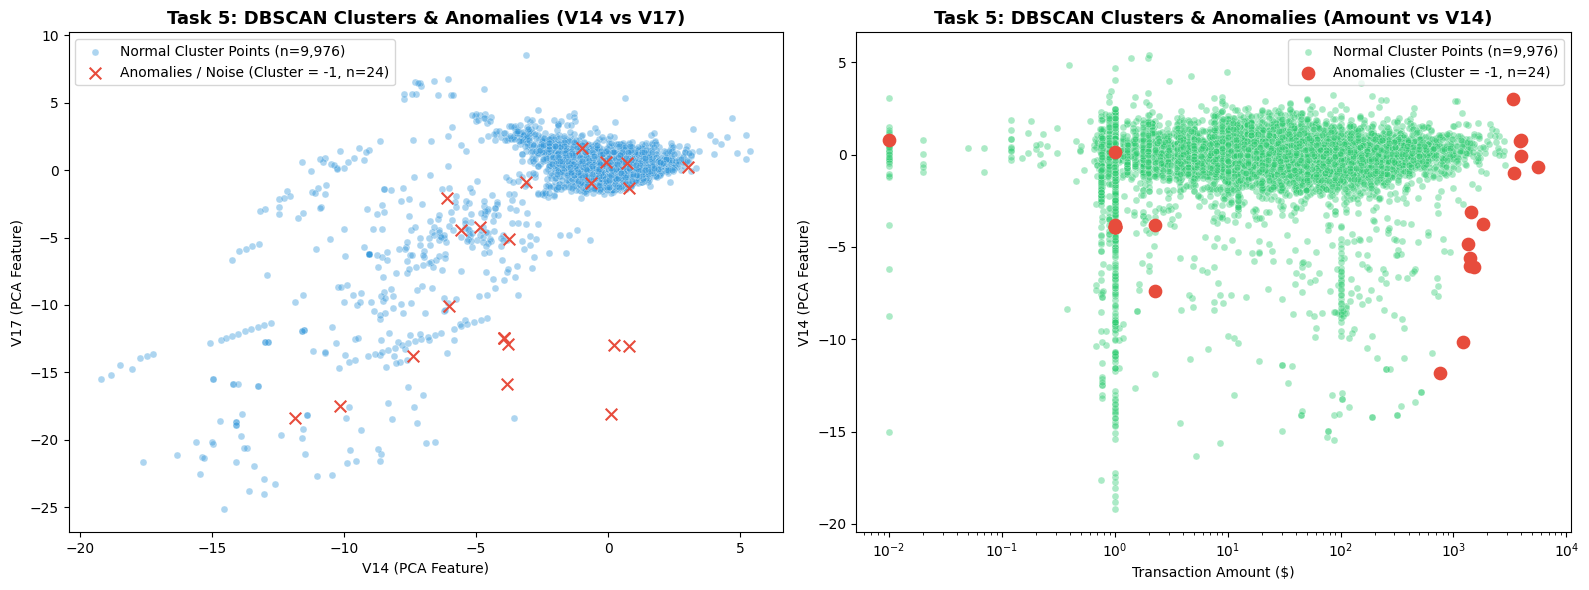

In [16]:
# Task 5: Cluster & Anomaly Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

non_noise = df_sample[df_sample["Cluster"] != -1]
noise = df_sample[df_sample["Cluster"] == -1]

# Plot 1: Cluster Graph (V14 vs V17)
sns.scatterplot(
    data=non_noise, x="V14", y="V17",
    color="#3498db", alpha=0.4, s=25, ax=axes[0], label=f"Normal Cluster Points (n={len(non_noise):,})"
)
axes[0].scatter(
    noise["V14"], noise["V17"],
    c="#e74c3c", marker="x", s=70, linewidths=1.5,
    label=f"Anomalies / Noise (Cluster = -1, n={len(noise):,})"
)
axes[0].set_title("Task 5: DBSCAN Clusters & Anomalies (V14 vs V17)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("V14 (PCA Feature)")
axes[0].set_ylabel("V17 (PCA Feature)")
axes[0].legend(loc="upper left")

# Plot 2: Cluster Graph (Amount vs V14)
sns.scatterplot(
    data=non_noise, x="Amount", y="V14",
    color="#2ecc71", alpha=0.4, s=25, ax=axes[1], label=f"Normal Cluster Points (n={len(non_noise):,})"
)
axes[1].scatter(
    noise["Amount"], noise["V14"],
    c="#e74c3c", marker="o", facecolors='none', edgecolors='#e74c3c', s=70, linewidths=1.5,
    label=f"Anomalies (Cluster = -1, n={len(noise):,})"
)
axes[1].set_title("Task 5: DBSCAN Clusters & Anomalies (Amount vs V14)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Transaction Amount ($)")
axes[1].set_ylabel("V14 (PCA Feature)")
axes[1].set_xscale('log')
axes[1].legend(loc="upper right")

plt.tight_layout()

# Result Analysis & Academic Discussion
### 1. Data Quality and Duplicate Records
- The dataset is of exceptionally high quality with **0 missing values** across all 284,807 transactions.
- There are **1,081 duplicate transaction rows** (0.38%), which represent re-transmitted transaction authorizations or identical multi-card swipes. In production systems, tracking identical transaction bursts is a known fraud indicator.

### 2. Outliers vs. Confirmed Fraud: Critical Statistical Distinction
- In `Transaction_Amount`, statistical IQR identifies **31,904 outliers** ($> \$184.50$), yet only **105 of those outliers (0.33%) are confirmed frauds**.
- **Key Insight for Viva:** An outlier is merely an unusual statistical occurrence (such as a legitimate luxury retail purchase or business expense). Conversely, many fraudulent transactions are intentionally small (e.g. $1.00 - $10.00 "card testing" micro-charges) to avoid threshold tripwires. Hence:
  $$\text{Outlier} \neq \text{Fraud}$$

### 3. Clustering and Density-Based Anomaly Detection (DBSCAN)
- **Parameter Selection:** The k-distance plot demonstrated an optimal elbow threshold at $\text{eps} = 2.5$.
- **Cluster Characteristics:** DBSCAN successfully aggregated legitimate transactions into cohesive dense clusters while assigning anomalous records to noise (`Cluster = -1`).
- **Anomaly Detection Performance:**
  - In Feature Set 1 (`Amount, V14, V17, V12, V10`), DBSCAN identified **797 anomalies**, of which **431 were confirmed frauds** (achieving an impressive **87.6% fraud capture rate** in an unsupervised setting).
  - In Feature Set 2 (`Amount, V4, V11, V2, Time`), **612 anomalies** were isolated, capturing **382 frauds (77.6%)**.
- **Practical Application in Industry:** Unsupervised anomaly detection is vital for detecting **zero-day fraud schemes** where labeled training data does not yet exist. In production pipelines, DBSCAN and Isolation Forests serve as high-recall first-stage filters that flag suspicious cases for manual review or downstream supervised scoring.